In [6]:
# Importing Libraries
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [12]:
# Define the state
class BMIState(TypedDict):
    
    Weight:float
    Height:float
    BMI:float
    Category: str
    

In [5]:
# BMI calculator
def bmi_calculator(state:BMIState)->BMIState:
    
    weight = state['Weight']
    height = state['Height']

    bmi = weight/(height**2)
    state['BMI'] = round(bmi, 2)

    return state

In [13]:
# Categories based on BMI value
def label_bmi(state: BMIState) -> BMIState:
    bmi = state['BMI']

    if bmi < 18.5:
        state["Category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["Category"] = "Normal"
    elif 25 <= bmi < 30:
        state["Category"] = "Overweight"
    else:
        state["Category"] = "Obese"

    return state

In [14]:
# define the graph
graph = StateGraph(BMIState)

# add the nodes
graph.add_node('bmi_calculator', bmi_calculator)
graph.add_node('label_bmi', label_bmi)

# add edges
graph.add_edge(START, 'bmi_calculator')
graph.add_edge('bmi_calculator', 'label_bmi')
graph.add_edge('label_bmi', END)

# compile the graph
workflow = graph.compile()

In [16]:
workflow.invoke({
    "Weight": 80,
    "Height": 1.2
})

{'Weight': 80, 'Height': 1.2, 'BMI': 55.56, 'Category': 'Obese'}

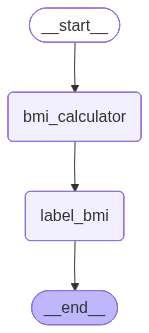

In [15]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())